### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [6]:
data = pd.read_csv('data/coupons.csv')

In [7]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [9]:
# Dataset structure
data.info()

# Count missing values
missing = (
    data.isnull()
        .sum()
        .sort_values(ascending=False)
        .to_frame("missing_count")
)

missing["missing_percent"] = (
    missing["missing_count"] / len(data) * 100
)

display(missing)

# Check for identical rows
duplicate_count = data.duplicated().sum()
print("Duplicated rows:", duplicate_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

,missing_count,missing_percent
car,12576,99.148534
CoffeeHouse,217,1.710817
Restaurant20To50,189,1.490066
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Bar,107,0.843582
destination,0,0.000000
passanger,0,0.000000
direction_opp,0,0.000000
direction_same,0,0.000000


Duplicated rows: 74


### Data-Quality Observations

The 'car' column contains 12,576 missing values out of 12,684
observations, so it cannot provide reliable information. The remaining
missing values occur in the customer-frequency columns and represent a
relatively small portion of the dataset.

The dataset also contains 74 completely identical rows. Because the
dataset does not include a unique respondent identifier, it is not
possible to determine whether these rows are accidental duplicates or
different respondents with identical survey responses. Therefore, I
will retain them rather than risk removing valid observations.

For the missing data, I will remove the 'car' column and remove rows
with missing values in the remaining columns.

3. Decide what to do about your missing data -- drop, replace, other...

In [12]:

# Create a separate copy so the original DataFrame remains unchanged.
data_clean = (
    data.drop(columns=["car"])
        .dropna()
        .copy()
)

# Compare the number of rows and columns before and after cleaning.
print("Original shape:", data.shape)
print("Cleaned shape:", data_clean.shape)

# Cleaned DataFrame contains no remaining missing values.
print(
    "Remaining missing values:",
    data_clean.isnull().sum().sum()
)

Original shape: (12684, 26)
Cleaned shape: (12079, 25)
Remaining missing values: 0


### Cleaning decision

The 'car' column was removed because approximately 99% of its values
were missing. After removing that column, rows containing missing
values in the remaining customer-frequency variables were removed.
This retained 12,079 of the original 12,684 observations.

4. What proportion of the total observations chose to accept the coupon?



In [15]:
# Overall Coupon Acceptance Rate

overall_acceptance = data_clean["Y"].mean()

print(f"Overall acceptance rate: {overall_acceptance:.2%}")

Overall acceptance rate: 56.93%


Approximately 56.9% of the customers in the cleaned dataset accepted
the coupon.

5. Use a bar plot to visualize the `coupon` column.

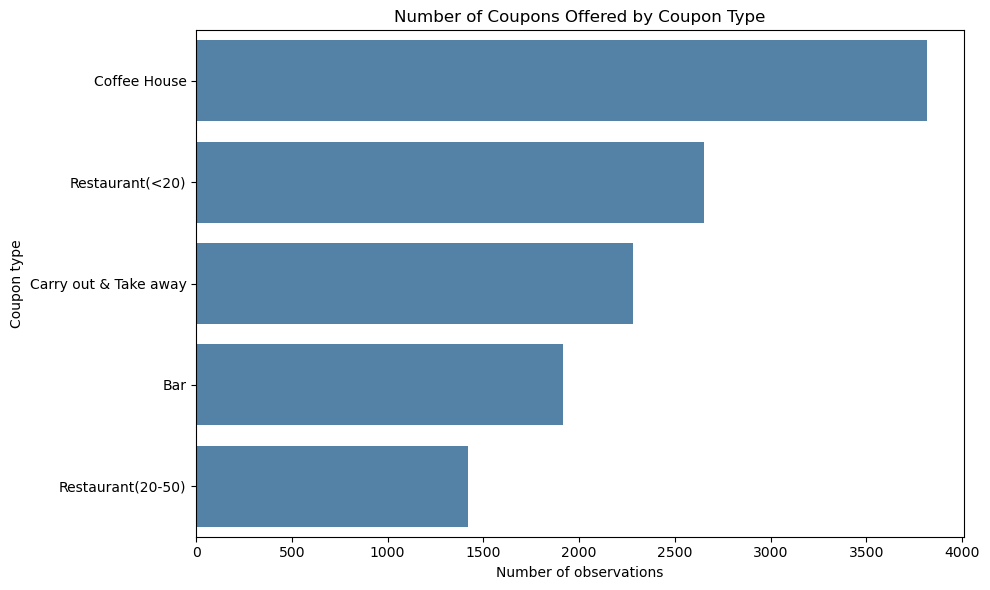

In [18]:
# Plot

plt.figure(figsize=(10, 6))

coupon_order = data_clean["coupon"].value_counts().index

sns.countplot(
    data=data_clean,
    y="coupon",
    order=coupon_order,
    color="steelblue"
)

plt.title("Number of Coupons Offered by Coupon Type")
plt.xlabel("Number of observations")
plt.ylabel("Coupon type")
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

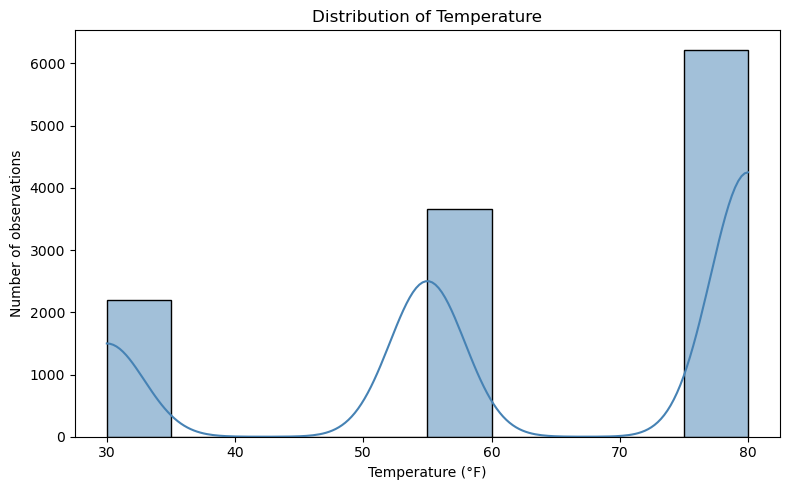

In [20]:
# Plot

plt.figure(figsize=(8, 5))

sns.histplot(
    data=data_clean,
    x="temperature",
    bins=10,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°F)")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [22]:
# Bar Coupons

bar_data = data_clean[
    data_clean["coupon"] == "Bar"
].copy()

bar_data.shape

(1913, 25)

2. What proportion of bar coupons were accepted?


In [24]:
# Bar coupon acceptance rate

bar_acceptance = bar_data["Y"].mean()

print(f"Bar coupon acceptance rate: {bar_acceptance:.2%}")

Bar coupon acceptance rate: 41.19%


Approximately 41.2% of the bar coupons were accepted, which is lower
than the overall coupon acceptance rate of approximately 56.9%.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Three or fewer visits: 37.27%
More than three visits: 76.17%


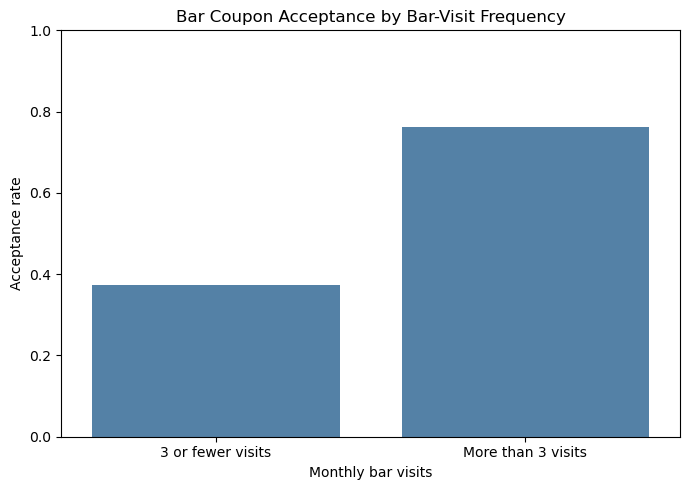

In [27]:
# category Groups
three_or_fewer = ["never", "less1", "1~3"]
more_than_three = ["4~8", "gt8"]


# Rate Caluclation

three_or_fewer_rate = bar_data.loc[
    bar_data["Bar"].isin(three_or_fewer),
    "Y"
].mean()

more_than_three_rate = bar_data.loc[
    bar_data["Bar"].isin(more_than_three),
    "Y"
].mean()

print(f"Three or fewer visits: {three_or_fewer_rate:.2%}")
print(f"More than three visits: {more_than_three_rate:.2%}")


# Chart Creation
comparison = pd.Series({
    "3 or fewer visits": three_or_fewer_rate,
    "More than 3 visits": more_than_three_rate
})

plt.figure(figsize=(7, 5))
sns.barplot(
    x=comparison.index,
    y=comparison.values,
    color="steelblue"
)
plt.title("Bar Coupon Acceptance by Bar-Visit Frequency")
plt.xlabel("Monthly bar visits")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Drivers who visited bars more than three times per month accepted approximately 76.2% of bar coupons. 
Drivers who visited bars three or fewer times accepted approximately 37.3%. 
Frequent bar visitors were therefore substantially more receptive to bar coupons.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [30]:
more_than_once = ["1~3", "4~8", "gt8"]

# Condition
frequent_over_25 = (
    bar_data["Bar"].isin(more_than_once)
    & ~bar_data["age"].isin(["below21", "21"])
)


# Calculate the Acceptance Rate
frequent_over_25_rate = bar_data.loc[
    frequent_over_25,
    "Y"
].mean()

all_others_rate = bar_data.loc[
    ~frequent_over_25,
    "Y"
].mean()

print(
    "More than once per month and over 25:",
    f"{frequent_over_25_rate:.2%}"
)

print(
    "All other drivers:",
    f"{all_others_rate:.2%}"
)


More than once per month and over 25: 68.98%
All other drivers: 33.77%


Drivers over age 25 who visited bars more than once per month accepted
approximately 69.98% of bar coupons, compared with approximately 33.77%
for all other drivers. This is a substantial difference.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [33]:
# Frequent bar visitors who were not traveling with children and did not work in farming, fishing, or forestry.
target_group_5 = (
    bar_data["Bar"].isin(more_than_once)
    & (bar_data["passanger"] != "Kid(s)")
    & (
        bar_data["occupation"]
        != "Farming Fishing & Forestry"
    )
)

# Acceptance rate for the target group.
target_rate_5 = bar_data.loc[
    target_group_5,
    "Y"
].mean()

# Acceptance rate for all other bar-coupon recipients.
others_rate_5 = bar_data.loc[
    ~target_group_5,
    "Y"
].mean()

# Display
print(f"Target group: {target_rate_5:.2%}")
print(f"All others: {others_rate_5:.2%}")

Target group: 70.94%
All others: 29.79%


Frequent bar visitors who did not have a child passenger and were not employed in farming, fishing, or forestry accepted approximately 70.94%
of bar coupons. All other drivers accepted approximately 29.79%.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [36]:
# Income categories below $50,000.
income_below_50k = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
]

# Group 1: Frequent bar visitors without child passengers who were not widowed.
group_1 = (
    bar_data["Bar"].isin(more_than_once)
    & (bar_data["passanger"] != "Kid(s)")
    & (bar_data["maritalStatus"] != "Widowed")
)

# Group 2: Frequent bar visitors under age 30.
group_2 = (
    bar_data["Bar"].isin(more_than_once)
    & bar_data["age"].isin(["below21", "21", "26"])
)

# Group 3: Frequent inexpensive-restaurant visitors with income below $50,000.
group_3 = (
    bar_data["RestaurantLessThan20"].isin(["4~8", "gt8"])
    & bar_data["income"].isin(income_below_50k)
)

# Coupon acceptance rate for each group.
question_6_rates = pd.Series({
    "Frequent bar visitor,\nno child passenger,\nnot widowed":
        bar_data.loc[group_1, "Y"].mean(),

    "Frequent bar visitor\nunder age 30":
        bar_data.loc[group_2, "Y"].mean(),

    "Frequent cheap-restaurant visitor,\nincome below $50K":
        bar_data.loc[group_3, "Y"].mean()
})

# Calculated rates.
question_6_rates



Frequent bar visitor,\nno child passenger,\nnot widowed    0.709434
Frequent bar visitor\nunder age 30                         0.719512
Frequent cheap-restaurant visitor,\nincome below $50K      0.456456
dtype: float64

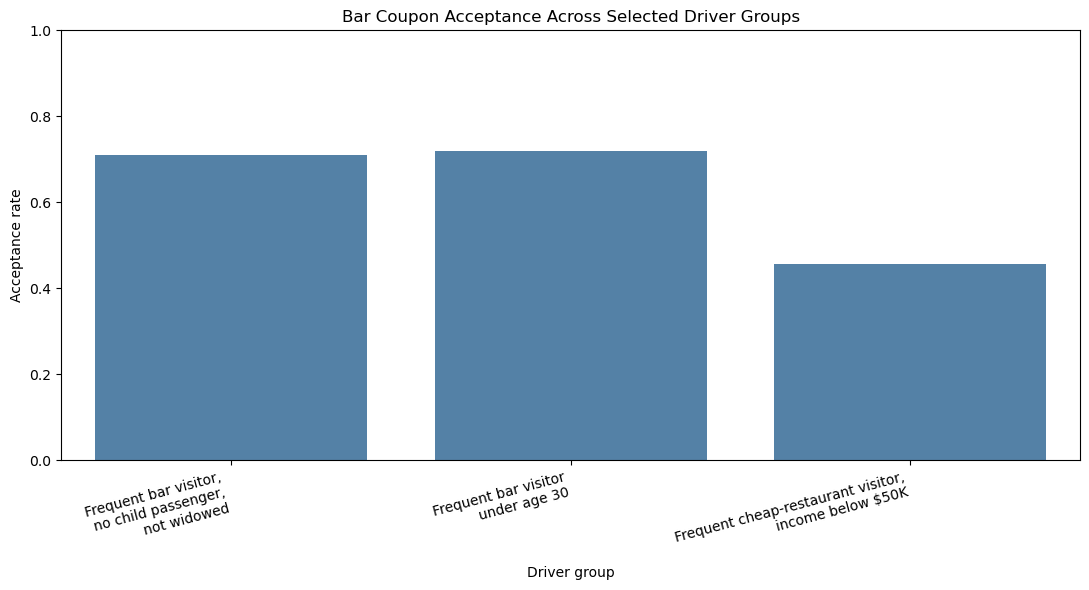

In [37]:
# Create a bar chart comparing the three groups.
plt.figure(figsize=(11, 6))

sns.barplot(
    x=question_6_rates.index,
    y=question_6_rates.values,
    color="steelblue"
)

# Readable labels and formatting.
plt.title("Bar Coupon Acceptance Across Selected Driver Groups")
plt.xlabel("Driver group")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Bar-coupon hypothesis

Bar coupons are most likely to be accepted by customers who already visit bars regularly. Frequent bar visitors had considerably higher
acceptance rates than infrequent visitors.

Age and passenger context may provide additional useful targeting information. Drivers under age 30 who visited bars more than once per
month had an acceptance rate of approximately 72%. Frequent visitors without child passengers also demonstrated relatively high acceptance.

These results suggest that bar coupons should be targeted toward existing bar customers, especially younger customers traveling without
children. The observed relationships are associations and do not establish that these characteristics cause coupon acceptance.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#### Independent Investigation: Coffee House Coupons

#### Investigation question

Which customer characteristics and driving circumstances are associated
with accepting Coffee House coupons?

In [42]:
# Subset
coffee_data = data_clean[
    data_clean["coupon"] == "Coffee House"
].copy()

coffee_data.shape

(3816, 25)

In [43]:
# Overall Coffee Acceptance Rate
coffee_acceptance = coffee_data["Y"].mean()

print(
    "Coffee House acceptance rate:",
    f"{coffee_acceptance:.2%}"
)

Coffee House acceptance rate: 49.63%


In [44]:
# Acceptance by Coffee - house visit frequency

coffee_frequency = (
    coffee_data.groupby("CoffeeHouse")["Y"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

coffee_frequency

,mean,count
CoffeeHouse,,
4~8,0.682446,507
gt8,0.657895,342
1~3,0.647694,1019
less1,0.480989,1052
never,0.175223,896


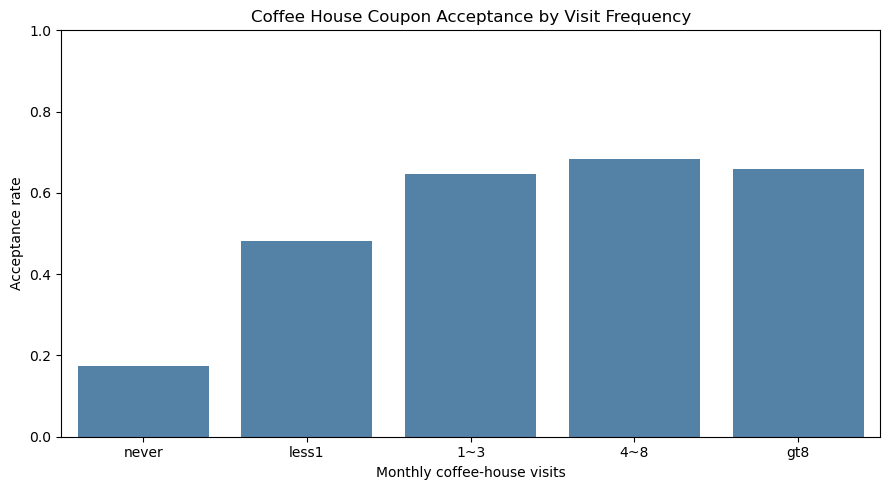

In [45]:
# Plot
frequency_order = [
    "never",
    "less1",
    "1~3",
    "4~8",
    "gt8"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=coffee_data,
    x="CoffeeHouse",
    y="Y",
    order=frequency_order,
    errorbar=None,
    color="steelblue"
)

plt.title("Coffee House Coupon Acceptance by Visit Frequency")
plt.xlabel("Monthly coffee-house visits")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

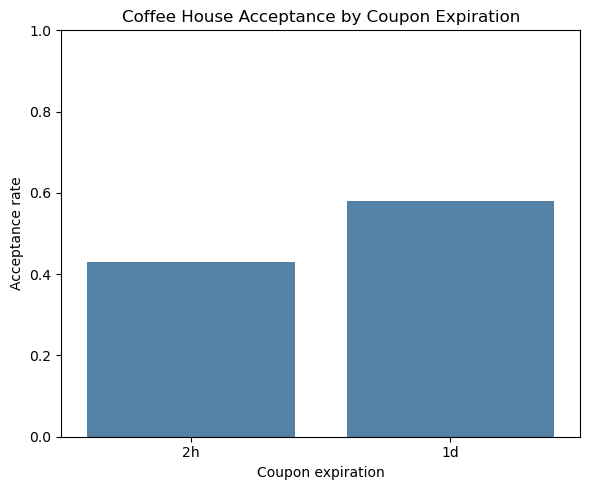

In [46]:
# Acceptance by expiration

expiration_rates = (
    coffee_data.groupby("expiration")["Y"].mean()
)

expiration_rates

# Plot
plt.figure(figsize=(6, 5))

sns.barplot(
    data=coffee_data,
    x="expiration",
    y="Y",
    errorbar=None,
    color="steelblue"
)

plt.title("Coffee House Acceptance by Coupon Expiration")
plt.xlabel("Coupon expiration")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


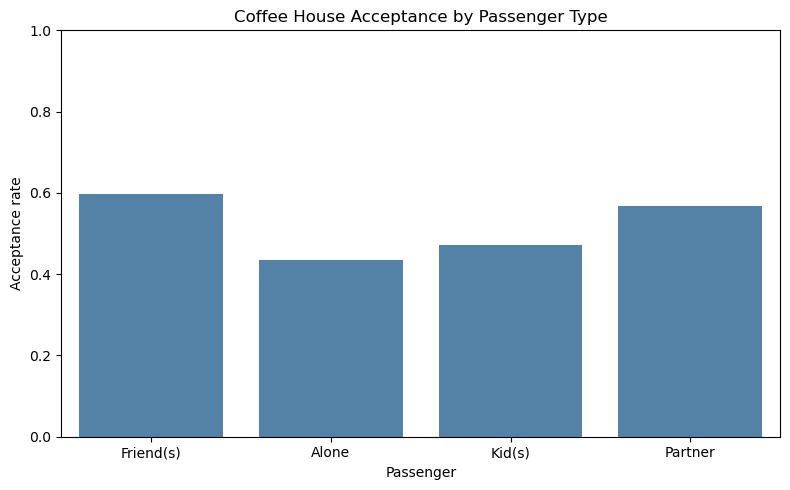

In [47]:
# Acceptance by passenger

passenger_rates = (
    coffee_data.groupby("passanger")["Y"]
    .mean()
    .sort_values(ascending=False)
)

passenger_rates

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coffee_data,
    x="passanger",
    y="Y",
    errorbar=None,
    color="steelblue"
)

plt.title("Coffee House Acceptance by Passenger Type")
plt.xlabel("Passenger")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

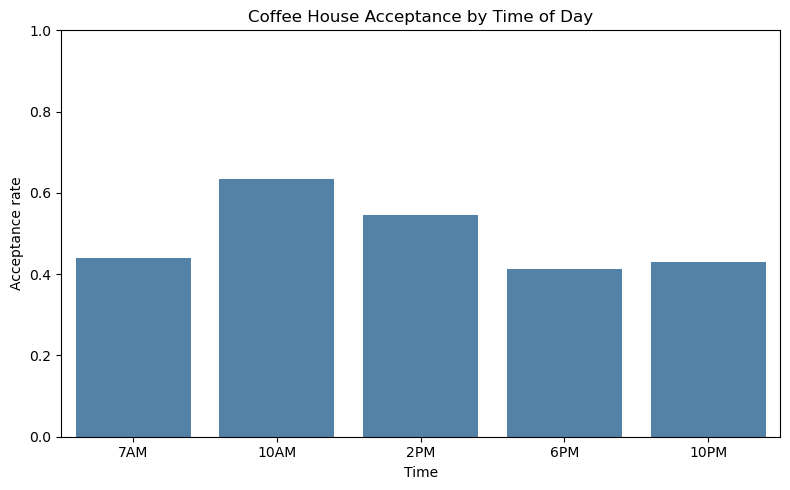

In [48]:
# Acceptance by Time
time_order = ["7AM", "10AM", "2PM", "6PM", "10PM"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=coffee_data,
    x="time",
    y="Y",
    order=time_order,
    errorbar=None,
    color="steelblue"
)

plt.title("Coffee House Acceptance by Time of Day")
plt.xlabel("Time")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#### Findings and Recommendations

#### Key Findings
- Overall coupon acceptance was approximately 56.9%.
- Bar coupons had a 41.2% acceptance rate.
- Frequent bar visitors accepted about 76.2% of bar coupons.
- Coffee House coupons had a 49.6% acceptance rate.
- Regular coffee-house customers, customers traveling with friends, and customers receiving one-day coupons were more likely to accept.
- Coffee House coupon acceptance was highest at 10 AM.

#### Recommendations
- Target coupons toward customers who already visit the relevant business.
- Send Bar coupons primarily to frequent bar visitors traveling without children.
- Prefer one-day Coffee House coupons delivered around 10 AM or 2 PM.
- Validate these findings with an A/B test before implementation.

#### Limitations
The analysis identifies associations between customer characteristics and stated coupon acceptance, but it does not prove causation or actual redemption. It also does not measure driving distraction, so future testing should use real redemption data and safe, hands-free delivery.